**Задание 1** Реализуйте функции, необходимые для вычисления правдоподобия и логарифма правдоподобия.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def p_hat(p, y):
    # p - предсказанная моделью вероятность класса 1
    # y - реальный класс (0 или 1)

    # функция должна вернуть вероятность класса y, при предсказании
    # модели p

    return p if y == 1 else (1 - p)


    # < YOUR CODE ENDS HERE >

def log_p_hat(p, y):
    return np.log(p_hat(p, y))

def likelihood(ps, ys):
    # ps - предсказанные вероятности класса 1 моделю для N объектов
    # ys - реальные классы N объектов

    # функция должна использовать p_hat и возвращать правдоподобие

    likelihood_ = None
    #правдоподобие = произведение вероятностей p_hat для всех объектов
    likelihood_ = 1.0
    for p, y in zip(ps, ys):
        likelihood_ *= p_hat(p, y)
    
    return likelihood_

def loglikelihood(ps, ys):
    # ps - предсказанные вероятности класса 1 моделю для N объектов
    # ys - реальные классы N объектов

    #функция должна использовать log_p_hat и возвращать логарифм правдоподобия
    #(на количество делить не нужно)

    p = np.clip(ps, a_min=1e-6, a_max=1-1e-6)
    log_probs = [log_p_hat(p, y) for (p, y) in zip(ps, ys)]
    loglikelihood_ = None
    
    #Логарифм правдоподобия = сумма логарифмов вероятностей
    loglikelihood_ = sum(log_probs)
    
    return loglikelihood_


In [3]:
test_ps = [0.1, 0.2, 0.3, 0.4]
test_ys = [0, 1, 0, 1]
assert likelihood(test_ps, test_ys) == 0.0504
assert np.allclose(np.log(likelihood(test_ps, test_ys)), loglikelihood(test_ps, test_ys))
print("Tests passed!")

Tests passed!


In [8]:
# Тестовые данные
test_ps = [0.1, 0.2, 0.3, 0.4]
test_ys = [0, 1, 0, 1]

print(" Детальный расчет:")
for i, (p, y) in enumerate(zip(test_ps, test_ys), 1):
    prob = p_hat(p, y)
    print(f"Объект {i}: p={p}, y={y} → p_hat={prob:.1f}")

print(f"\n Правдоподобие:")
L = likelihood(test_ps, test_ys)
print(f"L = {L:.4f}")
print("Проверка: 0.9 × 0.2 × 0.7 × 0.4 =", 0.9 * 0.2 * 0.7 * 0.4)

print(f"\n Логарифм правдоподобия:")
logL = loglikelihood(test_ps, test_ys)
print(f"log L = {logL:.6f}")

print("\n Проверка связи L и log L:")
print(f"exp(log L) = {np.exp(logL):.10f}")
print(f"L = {L:.10f}")
print(f"Они равны? {np.allclose(np.exp(logL), L)}")

# Выполняем тесты
print("\n Запуск тестов:")
try:
    assert np.allclose(L, 0.0504)
    print(" Тест 1 пройден: likelihood == 0.0504")
    
    assert np.allclose(np.log(L), logL)
    print(" Тест 2 пройден: log(likelihood) == loglikelihood")
    
    print("\n Все тесты пройдены!")
except AssertionError as e:
    print(f"✗ Тест не пройден: {e}")

 Детальный расчет:
Объект 1: p=0.1, y=0 → p_hat=0.9
Объект 2: p=0.2, y=1 → p_hat=0.2
Объект 3: p=0.3, y=0 → p_hat=0.7
Объект 4: p=0.4, y=1 → p_hat=0.4

 Правдоподобие:
L = 0.0504
Проверка: 0.9 × 0.2 × 0.7 × 0.4 = 0.0504

 Логарифм правдоподобия:
log L = -2.987764

 Проверка связи L и log L:
exp(log L) = 0.0504000000
L = 0.0504000000
Они равны? True

 Запуск тестов:
 Тест 1 пройден: likelihood == 0.0504
 Тест 2 пройден: log(likelihood) == loglikelihood

 Все тесты пройдены!


In [4]:
# В вашем основном ноутбуке
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# Импорт исправленного класса
from Neuron import Neuron, sigmoid, generate_simple_data, show_descision_boundary, eval_clf

# Создаем нейрон с сигмоидной активацией
neuron = Neuron(a=1, b=-1, c=0, prob_output=True)

# Генерируем данные
np.random.seed(42)
X = np.random.randn(10, 2)  # 10 точек
y_true = (X[:, 0] > X[:, 1]).astype(int)  # Истинные классы

# Предсказания нейрона (вероятности класса 1)
p_pred = neuron(X)

# Вычисляем правдоподобие
L = likelihood(p_pred, y_true)
log_L = loglikelihood(p_pred, y_true)

print(f"Предсказанные вероятности: {p_pred[:5]}...")
print(f"Истинные классы: {y_true[:5]}...")
print(f"Правдоподобие (L): {L:.10f}")
print(f"Логарифм правдоподобия (log L): {log_L:.6f}")
print(f"Проверка: exp(log L) = {np.exp(log_L):.10f} ≈ L")

# Для идеальных предсказаний (p=1 когда y=1, p=0 когда y=0)
ideal_ps = y_true.astype(float)  # 1.0 для класса 1, 0.0 для класса 0
ideal_ps = np.clip(ideal_ps, 1e-6, 1-1e-6)  # Избегаем log(0)

ideal_L = likelihood(ideal_ps, y_true)
ideal_logL = loglikelihood(ideal_ps, y_true)

print(f"\nДля идеальных предсказаний:")
print(f"L = {ideal_L:.6f} (максимально возможное)")
print(f"log L = {ideal_logL:.6f} (максимально возможное)")

Предсказанные вероятности: [0.65361745 0.2941441  0.4999959  0.69248827 0.2665819 ]...
Истинные классы: [1 0 0 1 0]...
Правдоподобие (L): 0.0197294686
Логарифм правдоподобия (log L): -3.925642
Проверка: exp(log L) = 0.0197294686 ≈ L

Для идеальных предсказаний:
L = 0.999990 (максимально возможное)
log L = -0.000010 (максимально возможное)


**Задание 2** Применение принципа максимума правдоподобия на практике.

Предположим у нас имеется монетка, подбросив которую 10 раз мы получили следующие результаты (0 -- решка, 1 -- орел):

$$
y = [1, 0, 1, 1, 1, 1, 0, 0, 0, 1]
$$

Наша задача узнать "параметры" этой монетки, а именно вероятность выпадения орла ($p$).

Интуитивно понятно, что $p=0.6$, но давайте теперь получим это значение с помощью принципа максимума правдоподобия.

Ваша задача используя код ниже показать что правдоподобие и его логарифм достигают экстремумов в 0.6. Мы будем это делать "в лоб". А именно мы посчитаем их значения для всех возможных вероятностей (с шагом 0.01) и визуально оценим их.

*Подсказка: монетка это модель, которая не зависит от объекта и имеет только один параметр -- с какой вероятностью она выпадает орлом.*


In [9]:
coins = np.array([1, 0, 1, 1, 1, 1, 0, 0, 0, 1])

N = 100
p_to_try =  np.linspace(0, 1, N)


# Переменная liks должна содержать значения правдоподобия для каждой из 100 вероятностей в p_to_try.
# Переменная logliks должна содержать значения логарифма правдоподобия для каждой из 100 вероятностей в p_to_try.

liks = []
logliks = []

for p in p_to_try:
    #Для каждой вероятности p вычисляем правдоподобие для всех монеток
    #Считаем количество орлов и решек
    num_heads = np.sum(coins == 1)  # количество единиц (орлов)
    num_tails = np.sum(coins == 0)  # количество нулей (решек)
    
    #Добавляем маленькое число чтобы избежать 0^0
    eps = 1e-10
    p_clipped = np.clip(p, eps, 1-eps)
    
    likelihood = (p_clipped ** num_heads) * ((1 - p_clipped) ** num_tails)
    liks.append(likelihood)
    
    #Логарифм правдоподобия
    log_likelihood = num_heads * np.log(p_clipped) + num_tails * np.log(1 - p_clipped)
    logliks.append(log_likelihood)

#Преобразуем в numpy массивы
liks = np.array(liks)
logliks = np.array(logliks)

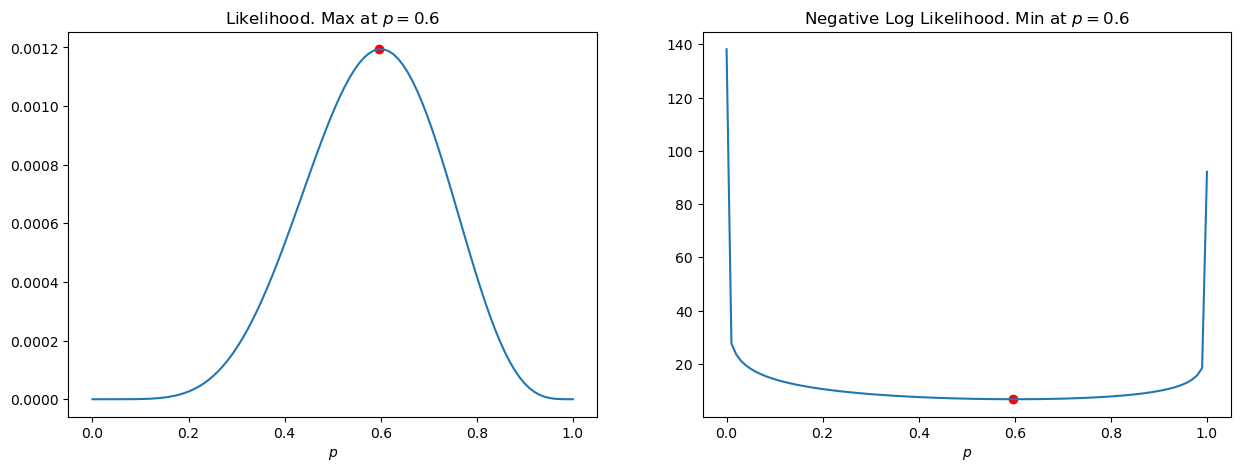

In [10]:
max_lik_ind = np.argmax(liks)
max_loglik_ind = np.argmax(logliks)

fig = plt.figure(figsize=(15, 5))
grid = plt.GridSpec(1, 2)
plt.subplot(grid[0, 0])
plt.plot(p_to_try, liks)
plt.xlabel("$p$")
plt.title(f"Likelihood. Max at $p={p_to_try[max_lik_ind]:.2}$")
plt.scatter(p_to_try[max_lik_ind], liks[max_lik_ind], c='red')

plt.subplot(grid[0, 1])
plt.plot(p_to_try, -np.array(logliks))
plt.scatter(p_to_try[max_loglik_ind], -logliks[max_loglik_ind], c='red')
plt.title(f"Negative Log Likelihood. Min at $p={p_to_try[max_loglik_ind]:.2}$")
_ = plt.xlabel("$p$")

In [14]:
coins = np.array([1, 0, 1, 1, 1, 1, 0, 0, 0, 1])
n = len(coins)  # 10
m = np.sum(coins == 1) 
p_optimal = m / n

print(f"Максимум правдоподобия {p_optimal:.2f}")


Максимум правдоподобия 0.60


In [20]:
#доказательство
#создаем пустой список для парвдоподобий
liks = []
N = 11  
#создаем  список значений p для проверки
p_to_try = np.linspace(0, 1, N)
#для каждого p вычисляем правдоподобие
for p in p_to_try:
    #численный расчет правдоподобия для каждого p в соответствии с заданными m и n
    likelihood = (p ** m) * ((1 - p) ** (n - m))
    liks.append(likelihood)
#print("список: ", liks)
#численный поиск максимума
print("Значения правдоподобия:")
for i, (p, lik) in enumerate(zip(p_to_try, liks)):
    print(f"p={p:.2f}: L(p)={lik:.6f}")
print()
max_idx = np.argmax(liks)  
p_numerical = p_to_try[max_idx]  # ≈ 0.6
print(f"Максимум правдоподобия {p_to_try[max_idx]:.2f}")

Значения правдоподобия:
p=0.00: L(p)=0.000000
p=0.10: L(p)=0.000001
p=0.20: L(p)=0.000026
p=0.30: L(p)=0.000175
p=0.40: L(p)=0.000531
p=0.50: L(p)=0.000977
p=0.60: L(p)=0.001194
p=0.70: L(p)=0.000953
p=0.80: L(p)=0.000419
p=0.90: L(p)=0.000053
p=1.00: L(p)=0.000000

Максимум правдоподобия 0.60


**Задание 3 (бонусное)**
Попробуйте доказать что максимум правдоподобия для задачи с монеткой достигается в общем случае при $p = \frac{m}{N}$ , где $m$ -- количество выпавших единиц, а $N$ -- общее число подбрасываний. *Рекомендуем предварительно воспользоваться логарифмированием (т.е. перейти максимизировать log likelihood)*